# Lab 7: Deep Learning for Multiclass Classification
## Multiclass Classification for Covertype Dataset
This notebook demonstrates a step-by-step implementation of a neural network for multiclass classification using the Covertype dataset. The goal is to classify forest cover types based on input features.

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
devices = tf.config.list_physical_devices('GPU')

if devices:
    for device in devices:
        details = tf.config.experimental.get_device_details(device)
        print(f"TensorFlow GPU:0 -> {details['device_name']}")
else:
    print("ไม่พบ GPU")

TensorFlow GPU:0 -> NVIDIA GeForce RTX 4050 Laptop GPU


## Step 1: Load and Preprocess the Data
We load the Covertype dataset, split it into training and test sets, standardize the features, and one-hot encode the target labels for multiclass classification.

Classes: 7
<br/>Samples total: 581012
<br/>Features: 54
<br/>Features type:int

1. Elevation / quantitative /meters / Elevation in meters
2. Aspect / quantitative / azimuth / Aspect in degrees azimuth
3. Slope / quantitative / degrees / Slope in degrees
4. Horizontal_Distance_To_Hydrology / quantitative / meters / Horz Dist to nearest surface water features
5. Vertical_Distance_To_Hydrology / quantitative / meters / Vert Dist to nearest surface water features
6. Horizontal_Distance_To_Roadways / quantitative / meters / Horz Dist to nearest roadway
7. Hillshade_9am / quantitative / 0 to 255 index / Hillshade index at 9am, summer solstice
8. Hillshade_Noon / quantitative / 0 to 255 index / Hillshade index at noon, summer soltice
9. Hillshade_3pm / quantitative / 0 to 255 index / Hillshade index at 3pm, summer solstice
10. Horizontal_Distance_To_Fire_Points / quantitative / meters / Horz Dist to nearest wildfire ignition points
11. Wilderness_Area (4 binary columns) / qualitative / 0 (absence) or 1 (presence) / Wilderness area designation
12. Soil_Type (40 binary columns) / qualitative / 0 (absence) or 1 (presence) / Soil Type designation
13. Cover_Type (7 types) / integer / 1 to 7 / Forest Cover Type designation
<br/>Target: Cover_Type

In [3]:
# Load the Covertype dataset to a pandas DataFrame(df)
CSV_PATH = 'cover_dataset.csv'
df = pd.read_csv(CSV_PATH)
df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,target
0,0.368684,0.141667,0.045455,0.184681,0.223514,0.071659,0.870079,0.913386,0.582677,0.875366,...,0,0,0,0,0,0,0,0,0,5
1,0.365683,0.155556,0.030303,0.151754,0.215762,0.054798,0.866142,0.925197,0.594488,0.867838,...,0,0,0,0,0,0,0,0,0,5
2,0.472736,0.386111,0.136364,0.191840,0.307494,0.446817,0.921260,0.937008,0.531496,0.853339,...,0,0,0,0,0,0,0,0,0,2
3,0.463232,0.430556,0.272727,0.173228,0.375969,0.434172,0.937008,0.937008,0.480315,0.865886,...,0,0,0,0,0,0,0,0,0,2
4,0.368184,0.125000,0.030303,0.109520,0.222222,0.054939,0.866142,0.921260,0.590551,0.860449,...,0,0,0,0,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,0.268634,0.425000,0.303030,0.060845,0.245478,0.015175,0.944882,0.933071,0.464567,0.116688,...,0,0,0,0,0,0,0,0,0,3
581008,0.266133,0.422222,0.287879,0.047960,0.239018,0.013348,0.944882,0.933071,0.468504,0.117803,...,0,0,0,0,0,0,0,0,0,3
581009,0.263632,0.441667,0.257576,0.042949,0.232558,0.012646,0.929134,0.948819,0.511811,0.119058,...,0,0,0,0,0,0,0,0,0,3
581010,0.262631,0.472222,0.227273,0.042949,0.229974,0.012646,0.905512,0.964567,0.562992,0.120452,...,0,0,0,0,0,0,0,0,0,3


In [4]:
# Separate the features(X) and labels(y)
X = df.drop(['target'], axis=1)
y = df['target']
# -------------------------------
# Your code here
# -------------------------------

# Convert labels to integers (from 1-7 to 0-6 for classification)
# -------------------------------
# Your code here
y = y - 1
# -------------------------------

In [5]:
# Show the first 5 rows of the dataset
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,target
0,0.368684,0.141667,0.045455,0.184681,0.223514,0.071659,0.870079,0.913386,0.582677,0.875366,...,0,0,0,0,0,0,0,0,0,5
1,0.365683,0.155556,0.030303,0.151754,0.215762,0.054798,0.866142,0.925197,0.594488,0.867838,...,0,0,0,0,0,0,0,0,0,5
2,0.472736,0.386111,0.136364,0.191840,0.307494,0.446817,0.921260,0.937008,0.531496,0.853339,...,0,0,0,0,0,0,0,0,0,2
3,0.463232,0.430556,0.272727,0.173228,0.375969,0.434172,0.937008,0.937008,0.480315,0.865886,...,0,0,0,0,0,0,0,0,0,2
4,0.368184,0.125000,0.030303,0.109520,0.222222,0.054939,0.866142,0.921260,0.590551,0.860449,...,0,0,0,0,0,0,0,0,0,5


array([[<Axes: title={'center': 'Elevation'}>,
        <Axes: title={'center': 'Aspect'}>,
        <Axes: title={'center': 'Slope'}>,
        <Axes: title={'center': 'Horizontal_Distance_To_Hydrology'}>,
        <Axes: title={'center': 'Vertical_Distance_To_Hydrology'}>,
        <Axes: title={'center': 'Horizontal_Distance_To_Roadways'}>,
        <Axes: title={'center': 'Hillshade_9am'}>],
       [<Axes: title={'center': 'Hillshade_Noon'}>,
        <Axes: title={'center': 'Hillshade_3pm'}>,
        <Axes: title={'center': 'Horizontal_Distance_To_Fire_Points'}>,
        <Axes: title={'center': 'Wilderness_Area1'}>,
        <Axes: title={'center': 'Wilderness_Area2'}>,
        <Axes: title={'center': 'Wilderness_Area3'}>,
        <Axes: title={'center': 'Wilderness_Area4'}>],
       [<Axes: title={'center': 'Soil_Type1'}>,
        <Axes: title={'center': 'Soil_Type2'}>,
        <Axes: title={'center': 'Soil_Type3'}>,
        <Axes: title={'center': 'Soil_Type4'}>,
        <Axes: title={'

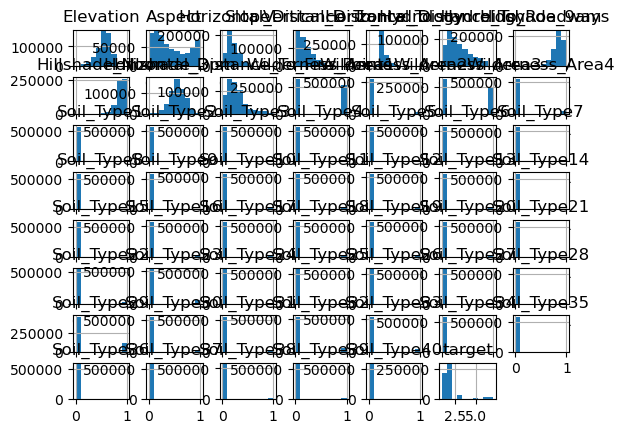

## Split and Scale the Dataset
We split the dataset into training and test sets with a test size of 20% and scale the features using the StandardScaler.

In [ ]:
# Split into training and test sets using 80% training and 20% testing
# Set random_state to 42 for reproducibility
# Use train_test_split function from scikit-learn
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
# Your code here
# -------------------------------

# Standardize the feature data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
df['target'].value_counts()


target
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64

In [11]:
df['target'].value_counts()

target
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64

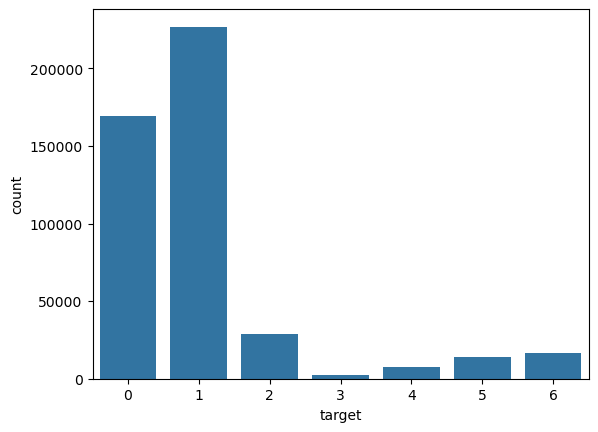

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train)
plt.show()

## Encode the Target Labels
We one-hot encode the target labels using the to_categorical function from the keras.utils module.

In [8]:
# One-hot encode the labels using to_categorical function from Keras
# -------------------------------
y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)
# Your code here
# -------------------------------


## Step 2: Build the Model
We define a neural network with multiple dense layers and dropout layers to prevent overfitting. The output layer uses a softmax activation for multiclass classification.

In [9]:
# Define the model
# Complete the code to build a Sequential model
# The model should have 4 Dense layers with 256, 128, 64, and 7 units
# Use 'relu' activation function for the first 3 layers and 'softmax' for the last layer
# Add Dropout layers with 0.3 dropout rate after the first 2 Dense layers

model = Sequential([
    Dense(256, activation='relu', input_shape=(54,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(7, activation='softmax')
])


/home/suggus/miniconda3/envs/deep_learning/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1772080521.335477    5229 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


## Step 3: Compile the Model
We compile the model using the Adam optimizer with a learning rate of 0.001, categorical crossentropy loss, and accuracy as the evaluation metric.

In [10]:
# Compile the model
# Use Adam optimizer with learning rate of 0.001
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
# -------------------------------
# Your code here
# -------------------------------

## Step 4: Train the Model
We train the model on the training data for 20 epochs, using a batch size of 64 and validating on the test set.

In [11]:
# Train the model
# Use 50 epochs and batch size of 32
# Use the training and test sets
# Save the training history to a variable(history)
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test,y_test), verbose=1)
# -------------------------------
# Your code here
# -------------------------------

Epoch 1/50


2026-02-26 11:35:23.844490: I external/local_xla/xla/service/service.cc:163] XLA service 0x79ea6c00a570 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-26 11:35:23.844520: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-02-26 11:35:23.881337: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-26 11:35:24.146113: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-02-26 11:35:24.263600: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-26 11:35:24.

   44/14526 ━━━━━━━━━━━━━━━━━━━━ 53s 4ms/step - accuracy: 0.3999 - loss: 1.5595   

I0000 00:00:1772080534.950332    5324 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 1071/14526 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.6408 - loss: 0.8865

KeyboardInterrupt: 

## Step 5: Evaluate the Model
We evaluate the model on the test set and print the test accuracy.

In [ ]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)
print(f"Test accuracy: {test_accuracy:.2f}")


2026-02-19 12:00:30.423084: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-19 12:00:30.423152: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-19 12:00:30.423161: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-19 12:00:31.410604: I external/l

3632/3632 - 12s - 3ms/step - accuracy: 0.9045 - loss: 0.2435
Test accuracy: 0.90


## Step 6: Make Predictions
We use the trained model to make predictions for the first 10 samples in the test set.

In [ ]:
# Make predictions
# Use the first 10 test data points to make predictions(predictions)
predictions = model.predict(X_test[:10])
# -------------------------------
# Your code here
# -------------------------------

# Show the predicted probabilities
print('\n Predicted Probabilities:')
print(f"{'Class 0':<10}{'Class 1':<10}{'Class 2':<10}{'Class 3':<10}{'Class 4':<10}{'Class 5':<10}{'Class 6':<10}")

for pred_prob in predictions:
    print(f"{pred_prob[0]:<10.3}{pred_prob[1]:<10.3}{pred_prob[2]:<10.3}{pred_prob[3]:<10.3}{pred_prob[4]:<10.3}{pred_prob[5]:<10.3}{pred_prob[6]:<10.3}")

2026-02-19 12:00:42.644228: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_18', 8 bytes spill stores, 8 bytes spill loads



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 907ms/step

 Predicted Probabilities:
Class 0   Class 1   Class 2   Class 3   Class 4   Class 5   Class 6   
0.902     0.00013   2.85e-14  9.72e-20  7.16e-08  2.2e-14   0.098     
0.141     0.792     0.00167   0.000969  0.0104    0.00614   0.0478    
0.00379   0.922     0.00555   2.62e-07  0.0302    0.0382    3.66e-06  
0.275     0.725     6.34e-12  4.42e-16  3.02e-07  2.21e-11  9.28e-08  
0.000164  0.92      9.76e-11  2.49e-17  0.0796    2.86e-09  5.02e-09  
9.22e-15  1.2e-06   0.999     6.16e-07  5.47e-11  0.00138   4.03e-21  
0.0912    0.909     2.8e-10   3.29e-15  5.73e-08  2.63e-11  2.18e-08  
0.999     0.000868  1.2e-13   7.94e-15  7.13e-07  6.52e-14  0.000579  
0.0713    0.929     5.31e-15  3.45e-19  1.18e-11  6.72e-15  3.84e-07  
0.00595   0.987     1.54e-07  3.44e-11  0.00711   3.78e-07  1.78e-07  


## Step 7: Interpret the Predictions
We convert the predicted probabilities into class labels using `np.argmax`, and compare them with the true labels.

In [ ]:
# Interpret the predictions
# Use np.argmax() to get the predicted class labels from the predicted probabilities
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test[:10], axis=1)
# -------------------------------
# Your code here
# -------------------------------


# Show the predicted and true labels
print("Predicted labels:", predicted_labels)
print("True labels:", true_labels)


Predicted labels: [0 1 1 1 1 2 1 0 1 1]
True labels: [0 1 1 1 1 2 1 0 1 1]
